# Machine Learning tradicional com PyCaret
## O mesmo problema da rede neural, resolvido de outro jeito

No notebook `mlp.ipynb` construímos uma **rede neural** peça por peça: definimos camadas, escolhemos otimizador, escrevemos o laço de treino, implementamos parada antecipada. Foram dezenas de linhas de código e várias decisões manuais.

Aqui vamos resolver **exatamente o mesmo problema** — prever doença cardíaca — com **algoritmos clássicos de aprendizado de máquina** (regressão logística, árvores, florestas aleatórias, gradient boosting, SVM...) usando a biblioteca **PyCaret**.

### O que é o PyCaret?

É uma camada de automação sobre o scikit-learn. Em vez de escrever cada etapa, você declara *o que* quer e ele executa o *como*:

| Você escreve | O PyCaret faz |
|---|---|
| `setup(...)` | divide os dados, imputa faltantes, codifica categorias, normaliza escalas |
| `compare_models()` | treina ~15 algoritmos diferentes e monta um ranking com validação cruzada |
| `tune_model(...)` | busca os melhores hiperparâmetros do modelo escolhido |
| `plot_model(...)` | gera matriz de confusão, curva ROC, importância de variáveis |
| `finalize_model()` | retreina no conjunto completo, pronto para produção |

### Por que aprender os dois?

Porque a lição mais importante de ciência de dados aplicada é esta:

> **Rede neural raramente é a melhor escolha para dados tabulares.**

Para tabelas com poucos milhares de linhas — o caso da esmagadora maioria dos problemas reais de empresa — modelos baseados em árvores costumam empatar ou ganhar da rede neural, treinando em segundos e sendo muito mais fáceis de explicar. Ao final deste notebook você vai poder comparar os números lado a lado.

### Roteiro

| Passo | O que faremos |
|---|---|
| 1 | Carregar os dados **brutos** |
| 2 | `setup()` — deixar o PyCaret cuidar de todo o pré-processamento |
| 3 | `compare_models()` — competição entre os algoritmos |
| 4 | `tune_model()` — ajuste fino do vencedor |
| 5 | Gráficos de diagnóstico |
| 6 | Avaliação no *holdout* |
| 7 | Finalizar e salvar |
| 8 | Comparar com a rede neural |

> **Atenção ao ambiente:** este notebook precisa do kernel **`caret`**, não do `p_312` usado no `mlp.ipynb`. O PyCaret exige `numpy < 2` e não convive com o ambiente do PyTorch. Confira no canto superior direito antes de rodar.

In [1]:
!pip install -q ucimlrepo

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo

import pycaret
from pycaret.classification import *

SEED = 42
pd.set_option('display.max_columns', None)

print('PyCaret     :', pycaret.__version__)
print('pandas      :', pd.__version__)
print('numpy       :', np.__version__)

PyCaret     : 3.3.2
pandas      : 2.1.4
numpy       : 1.26.4


---
## Passo 1 — Carregar os dados **brutos**

Repare que **não** vamos usar o `heart_disease_woe.csv`. Dois motivos:

**1. Queremos que o PyCaret faça o encoding.** Aquele CSV já vem com as categorias convertidas em WOE. Se o usássemos, estaríamos entregando o trabalho pronto e o PyCaret não teria o que codificar.

**2. Aquele CSV carrega vazamento de dados.** O WOE foi calculado usando o alvo de **todos** os pacientes, antes de qualquer divisão treino/teste — o mesmo problema que corrigimos no `mlp.ipynb`. O `setup()` do PyCaret divide os dados **antes** de transformar, então partindo do bruto o vazamento não acontece.

Então carregamos tudo cru: categorias como números originais, faltantes ainda presentes.

In [2]:
heart = fetch_ucirepo(id=45)

df = heart.data.features.copy()

# O alvo original vai de 0 a 4 (grau de obstrução). Binarizamos:
# 0 = sem doença | 1,2,3,4 = com doença
df['num'] = (heart.data.targets['num'] > 0).astype(int)

print('shape:', df.shape)
print()
print('Valores faltantes por coluna:')
faltantes = df.isna().sum()
print(faltantes[faltantes > 0].to_string())
print()
print('Distribuição do alvo:')
print(df['num'].value_counts().rename({0: 'sem doença', 1: 'com doença'}).to_string())

df.head()

shape: (303, 14)

Valores faltantes por coluna:
ca      4
thal    2

Distribuição do alvo:
num
sem doença    164
com doença    139


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


---
## Passo 2 — `setup()`: todo o pré-processamento numa chamada

Esta única função substitui tudo o que fizemos à mão no `mlp.ipynb`:

| No `mlp.ipynb` escrevemos | Aqui é um argumento |
|---|---|
| `train_test_split(...)` | `train_size=0.8` |
| `SimpleImputer(strategy='median')` | `numeric_imputation='median'` |
| `ce.WOEEncoder(...)` | `max_encoding_ohe=25` |
| `StandardScaler()` | `normalize=True` |
| `Pipeline([...])` | montado internamente |

### Por que declaramos `categorical_features` explicitamente?

Este é o ponto mais importante da célula, e o erro mais fácil de cometer.

As colunas `cp`, `thal`, `restecg` e `slope` estão gravadas como **números inteiros** no arquivo — mas são **rótulos**, não quantidades. `cp=4` (assintomático) não é "o dobro" de `cp=2` (angina atípica); são apenas categorias diferentes que receberam códigos numéricos.

Se não avisarmos, o PyCaret olha o tipo da coluna (`int64`), conclui que é numérica e a entrega ao modelo como se fosse uma grandeza ordenada. O modelo então tenta encontrar uma tendência ao longo de `1 → 2 → 3 → 4` que **não existe**.

Declarando-as como categóricas, o PyCaret aplica **one-hot encoding**: cada categoria vira uma coluna 0/1, sem ordem implícita nenhuma.

> Repare que `ca` fica entre as **numéricas**. Ela é uma contagem — número de vasos obstruídos, de 0 a 3 — e aí a ordem e o espaçamento significam alguma coisa de verdade.

### E a validação cruzada

`fold=5` com `fold_strategy='stratifiedkfold'` significa que os 80% de treino serão divididos em 5 partes: o modelo treina em 4 e valida na 5ª, cinco vezes, alternando. Toda métrica reportada é a **média dessas 5 rodadas** — bem mais confiável que uma divisão única. Os 20% restantes ficam lacrados como *holdout*.

In [3]:
CATEGORICAS = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
NUMERICAS   = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']

exp = setup(
    data=df,
    target='num',
    session_id=SEED,

    train_size=0.8,                    # 80% treino+CV | 20% holdout lacrado

    categorical_features=CATEGORICAS,  # sem isto, cp/thal/slope virariam "números"
    numeric_features=NUMERICAS,

    numeric_imputation='median',       # preenche os faltantes de ca
    categorical_imputation='mode',     # preenche os faltantes de thal
    max_encoding_ohe=25,               # one-hot para colunas com até 25 categorias

    normalize=True,                    # média 0, desvio 1
    normalize_method='zscore',

    fold_strategy='stratifiedkfold',   # validação cruzada estratificada
    fold=5,

    verbose=True,
)

,Description,Value
0,Session id,42
1,Target,num
2,Target type,Binary
3,Original data shape,"(303, 14)"
4,Transformed data shape,"(303, 23)"
5,Transformed train set shape,"(242, 23)"
6,Transformed test set shape,"(61, 23)"
7,Numeric features,6
8,Categorical features,7
9,Rows with missing values,2.0%


---
## Passo 3 — `compare_models()`: a competição

Agora a parte que justifica sozinha o uso do PyCaret.

Esta única linha treina **cerca de 15 algoritmos diferentes**, cada um com validação cruzada de 5 dobras — ou seja, **75 treinamentos** — e devolve um ranking ordenado.

Alguns dos competidores:

| Sigla | Algoritmo | Ideia central |
|---|---|---|
| `lr` | Regressão Logística | uma fronteira reta entre as classes |
| `knn` | K-Vizinhos | classifica pelo que os casos parecidos fizeram |
| `nb` | Naive Bayes | probabilidades, supondo variáveis independentes |
| `dt` | Árvore de Decisão | sequência de perguntas sim/não |
| `rf` | Floresta Aleatória | centenas de árvores votando |
| `gbc` | Gradient Boosting | árvores que corrigem os erros das anteriores |
| `lightgbm` | LightGBM | boosting otimizado, o mais usado na indústria |
| `svm` / `rbfsvm` | Máquinas de Vetores de Suporte | busca a fronteira de maior margem |

Ordenamos por **AUC**, e não por acurácia, pelo mesmo motivo discutido no `mlp.ipynb`: a AUC não depende do limiar de decisão e não se deixa enganar por classes desbalanceadas.

> Leva de alguns segundos a um ou dois minutos. É o momento de comparar com o esforço de escrever uma rede neural do zero.

In [4]:
melhores = compare_models(sort='AUC', n_select=3)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lr,Logistic Regression,0.8262,0.8944,0.7652,0.8434,0.8015,0.6475,0.6512,1.0600
lda,Linear Discriminant Analysis,0.8427,0.8917,0.7834,0.8639,0.8201,0.6810,0.6855,0.0600
ridge,Ridge Classifier,0.8427,0.8913,0.7834,0.8639,0.8201,0.6810,0.6855,0.0520
rf,Random Forest Classifier,0.8055,0.8895,0.7470,0.8181,0.7778,0.6056,0.6108,0.1140
catboost,CatBoost Classifier,0.8181,0.8824,0.7743,0.8212,0.7949,0.6319,0.6351,0.7860
et,Extra Trees Classifier,0.8016,0.8806,0.7747,0.7875,0.7795,0.5994,0.6015,0.1120
svm,SVM - Linear Kernel,0.7975,0.8794,0.7739,0.7831,0.7772,0.5915,0.5932,0.0620
lightgbm,Light Gradient Boosting Machine,0.7932,0.8722,0.7648,0.7779,0.7711,0.5824,0.5828,0.1080
nb,Naive Bayes,0.6774,0.8667,0.9273,0.6205,0.7307,0.3782,0.4531,0.6300
xgboost,Extreme Gradient Boosting,0.7932,0.8659,0.7830,0.7699,0.7750,0.5836,0.5855,0.0720


### Lendo o placar

Cada linha é um algoritmo; cada coluna, a **média das 5 dobras** da validação cruzada.

| Coluna | Significado |
|---|---|
| `Accuracy` | fração de acertos |
| `AUC` | qualidade do ranqueamento (independe do limiar) |
| `Recall` | dos doentes, quantos foram encontrados |
| `Prec.` | dos apontados como doentes, quantos realmente eram |
| `F1` | média harmônica de precisão e recall |
| `Kappa` | acurácia corrigida pelo acaso |
| `MCC` | correlação entre previsto e real (bom para classes desbalanceadas) |
| `TT (Sec)` | tempo de treino, em segundos |

**O que observar:**

1. **A diferença entre o 1º e o 5º costuma ser pequena.** Se a distância for de poucos milésimos de AUC, ela provavelmente é ruído amostral — não escolha o vencedor como se fosse um veredito definitivo.

2. **Olhe a coluna `TT (Sec)`.** Modelos simples treinam em centésimos de segundo. Se um modelo complexo ganha por 0,003 de AUC mas leva 100 vezes mais tempo, o simples costuma ser a escolha melhor — especialmente porque é mais fácil de explicar a um médico.

3. **Regressão logística indo bem é um sinal importante.** Significa que o problema é aproximadamente linear, e que modelos sofisticados (incluindo a rede neural) não têm muito a acrescentar.

In [5]:
placar = pull()          # recupera a última tabela exibida pelo PyCaret

print('Ranking completo por AUC:')
print()
print(placar[['Accuracy', 'AUC', 'Recall', 'Prec.', 'F1', 'TT (Sec)']].round(4).to_string())

print()
print(f'Modelos treinados: {len(placar)}')
print(f'Melhor AUC : {placar["AUC"].max():.4f}')
print(f'Pior AUC   : {placar["AUC"].min():.4f}')
print(f'Diferença entre o 1º e o 3º: {placar["AUC"].iloc[0] - placar["AUC"].iloc[2]:.4f}')

Ranking completo por AUC:

          Accuracy     AUC  Recall   Prec.      F1  TT (Sec)
lr          0.8262  0.8944  0.7652  0.8434  0.8015     1.060
lda         0.8427  0.8917  0.7834  0.8639  0.8201     0.060
ridge       0.8427  0.8913  0.7834  0.8639  0.8201     0.052
rf          0.8055  0.8895  0.7470  0.8181  0.7778     0.114
catboost    0.8181  0.8824  0.7743  0.8212  0.7949     0.786
et          0.8016  0.8806  0.7747  0.7875  0.7795     0.112
svm         0.7975  0.8794  0.7739  0.7831  0.7772     0.062
lightgbm    0.7932  0.8722  0.7648  0.7779  0.7711     0.108
nb          0.6774  0.8667  0.9273  0.6205  0.7307     0.630
xgboost     0.7932  0.8659  0.7830  0.7699  0.7750     0.072
knn         0.8055  0.8555  0.7834  0.7950  0.7857     1.066
gbc         0.7972  0.8530  0.7557  0.7944  0.7725     0.078
ada         0.7768  0.8302  0.6933  0.7990  0.7397     0.070
dt          0.7310  0.7294  0.7190  0.7041  0.7058     0.060
qda         0.6486  0.6737  0.5664  0.6567  0.5873     0.0

---
## Passo 4 — `tune_model()`: ajuste fino

O `compare_models()` treinou todos os algoritmos com os **hiperparâmetros padrão**. Agora fazemos uma busca aleatória por combinações melhores no vencedor.

**Hiperparâmetro** é um ajuste que *nós* escolhemos, e que o modelo não aprende sozinho — a profundidade máxima de uma árvore, o número de vizinhos do KNN, a força da regularização. É o análogo do `lr` e do `p_dropout` que definimos na rede neural.

O `choose_better=True` é uma proteção importante: **a busca nem sempre encontra algo melhor**. Com esse argumento, se a versão ajustada ficar pior que a original na validação cruzada, o PyCaret devolve a original. Sem ele, você poderia sair com um modelo pior do que entrou.

> Toda essa busca acontece **dentro dos 80% de treino**, usando validação cruzada. O *holdout* continua lacrado.

In [6]:
melhor = melhores[0]
print('Vencedor do compare_models():', type(melhor).__name__)
print()

ajustado = tune_model(
    melhor,
    optimize='AUC',
    n_iter=50,             # 50 combinações de hiperparâmetros testadas
    choose_better=True,    # se a busca piorar, mantém o original
)

print()
print('Configuração final do modelo:')
print(ajustado)

Vencedor do compare_models(): LogisticRegression



,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9184,0.9532,0.8261,1.0000,0.9048,0.8345,0.8461
1,0.8163,0.8367,0.7273,0.8421,0.7805,0.6240,0.6290
2,0.8542,0.9073,0.8636,0.8261,0.8444,0.7073,0.7079
3,0.8333,0.9301,0.8182,0.8182,0.8182,0.6643,0.6643
4,0.7708,0.8514,0.6818,0.7895,0.7317,0.5336,0.5379
Mean,0.8386,0.8957,0.7834,0.8552,0.8159,0.6727,0.6771
Std,0.0484,0.0449,0.0677,0.0744,0.0584,0.0992,0.1014


Fitting 5 folds for each of 50 candidates, totalling 250 fits

Configuração final do modelo:
LogisticRegression(C=0.095, class_weight={}, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=1000,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=42, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)


---
## Passo 5 — Gráficos de diagnóstico

Quatro visualizações que respondem perguntas diferentes:

- **`confusion_matrix`** — que tipo de erro o modelo comete? (falso negativo é o grave aqui)
- **`auc`** — a curva ROC, com a área sob ela
- **`pr`** — curva precisão × recall, mais informativa que a ROC quando as classes são desbalanceadas
- **`feature`** — quais variáveis o modelo mais usou para decidir

O gráfico de importância é o que mais interessa a um médico: ele mostra se o modelo está olhando para as variáveis clinicamente plausíveis (`thal`, `cp`, `ca`, `thalach`) ou se encontrou algum atalho suspeito nos dados.

> Nem todo modelo expõe importância de variáveis — Naive Bayes e KNN, por exemplo, não têm esse conceito. Por isso a chamada está protegida por `try`.

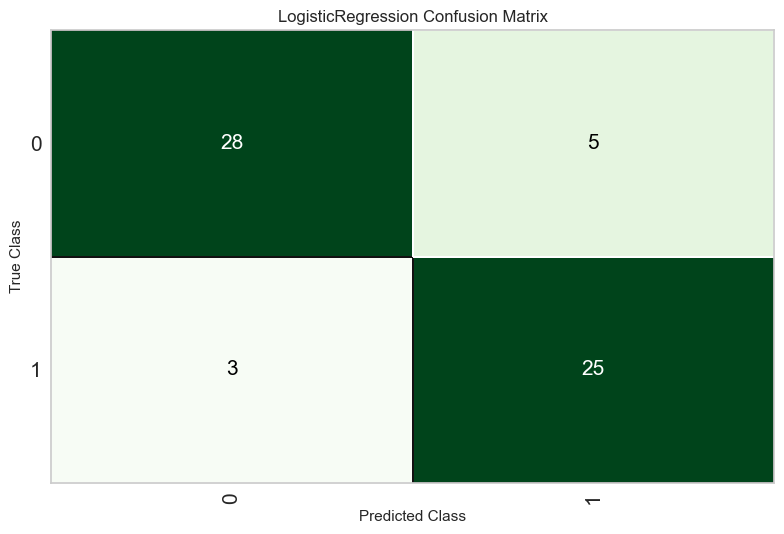

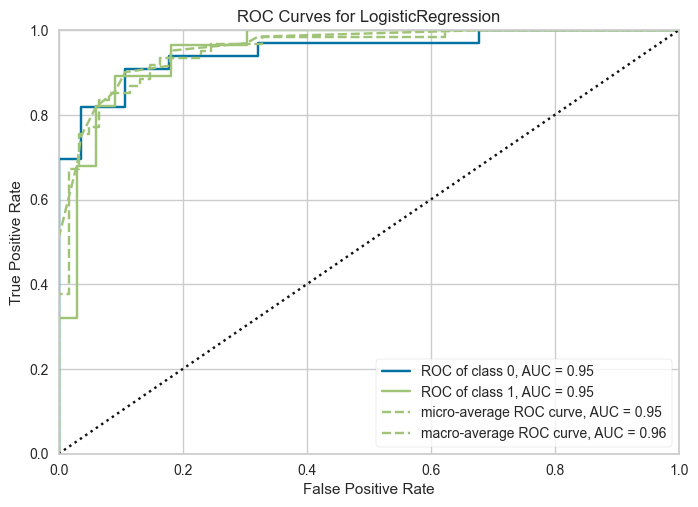

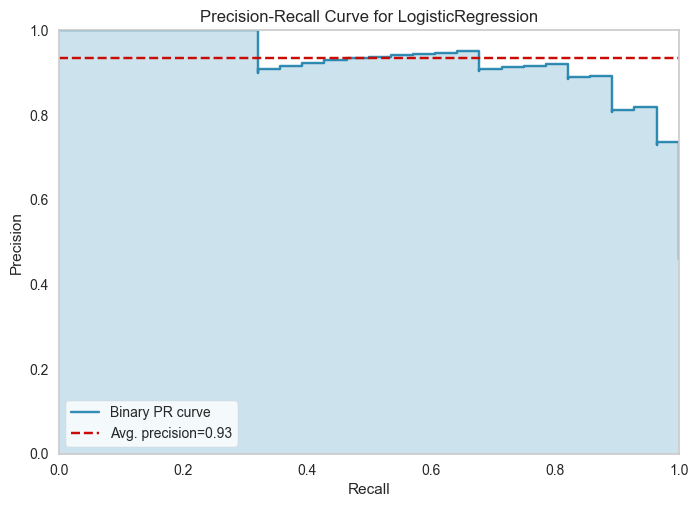

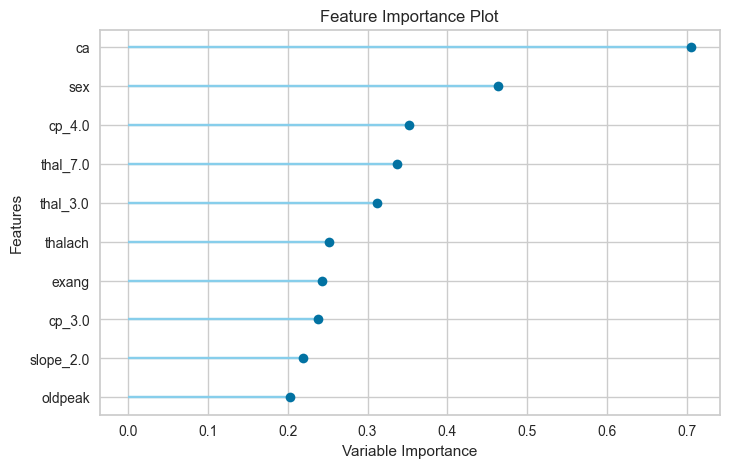

In [7]:
plot_model(ajustado, plot='confusion_matrix')
plot_model(ajustado, plot='auc')
plot_model(ajustado, plot='pr')

try:
    plot_model(ajustado, plot='feature')
except Exception as e:
    print(f'Este modelo não expõe importância de variáveis ({type(e).__name__}).')
    print('Modelos lineares e de árvore expõem; KNN e Naive Bayes não.')

---
## Passo 6 — Avaliação no *holdout*

Hora de abrir o cofre. O `predict_model()` aplica o modelo aos **20% que ficaram de fora** de tudo: da validação cruzada, do `compare_models()` e da busca de hiperparâmetros.

### Uma armadilha do PyCaret

A coluna `prediction_score` **não** é a probabilidade da classe 1 — é a probabilidade da **classe que foi prevista**. Para um paciente classificado como saudável com 80% de confiança, ela vale 0,80, e não 0,20.

Usar essa coluna direto no `roc_auc_score` produz um resultado errado, e é um erro comum. A solução é `raw_score=True`, que cria as colunas `prediction_score_0` e `prediction_score_1` separadas.

In [8]:
from sklearn.metrics import confusion_matrix, roc_auc_score
from imblearn.metrics import classification_report_imbalanced

# raw_score=True -> cria prediction_score_0 e prediction_score_1
pred = predict_model(ajustado, raw_score=True)

metricas_holdout = pull()

y_real = pred['num'].to_numpy()
y_prev = pred['prediction_label'].to_numpy()
prob1  = pred['prediction_score_1'].to_numpy()   # P(classe = 1), a correta para AUC

cm = confusion_matrix(y_real, y_prev)
vn, fp, fn, vp = cm.ravel()
total = cm.sum()

print(f'Holdout: {total} pacientes ({vp + fn} com doença, {vn + fp} sem)')
print()
print(metricas_holdout.round(4).to_string())

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Logistic Regression,0.8689,0.9502,0.8929,0.8333,0.8621,0.7374,0.7389


Holdout: 61 pacientes (28 com doença, 33 sem)

                 Model  Accuracy     AUC  Recall   Prec.      F1   Kappa     MCC
0  Logistic Regression    0.8689  0.9502  0.8929  0.8333  0.8621  0.7374  0.7389


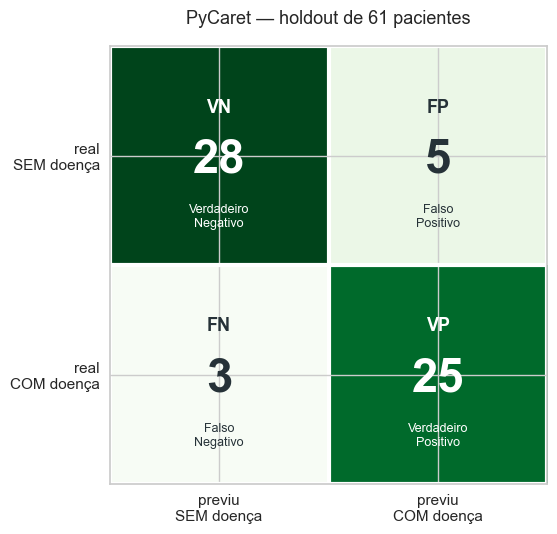

Acurácia       = (VP+VN)/total = (25+28)/61 = 0.869
Precisão       = VP/(VP+FP)    = 25/30     = 0.833
Recall         = VP/(VP+FN)    = 25/28     = 0.893
Especificidade = VN/(VN+FP)    = 28/33     = 0.848
F1                                    = 0.862
Média geométrica = sqrt(rec x spe)    = 0.870
AUC-ROC                               = 0.950

                   pre       rec       spe        f1       geo       iba       sup

 sem doença      0.903     0.848     0.893     0.875     0.870     0.754        33
 com doença      0.833     0.893     0.848     0.862     0.870     0.761        28

avg / total      0.871     0.869     0.872     0.869     0.870     0.757        61

Legenda: pre=precisão  rec=recall  spe=especificidade
         f1=harmônica  geo=geométrica  iba=acurácia balanceada  sup=suporte


In [9]:
# ---------------------------- o desenho ----------------------------
fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.imshow(cm, cmap='Greens')

siglas = [['VN', 'FP'], ['FN', 'VP']]
nomes  = [['Verdadeiro\nNegativo', 'Falso\nPositivo'],
          ['Falso\nNegativo', 'Verdadeiro\nPositivo']]

for i in range(2):
    for j in range(2):
        cor = 'white' if cm[i, j] > cm.max() * 0.6 else '#263238'
        ax.text(j, i - 0.22, siglas[i][j], ha='center', va='center',
                fontsize=13, fontweight='bold', color=cor)
        ax.text(j, i + 0.02, str(cm[i, j]), ha='center', va='center',
                fontsize=34, fontweight='bold', color=cor)
        ax.text(j, i + 0.28, nomes[i][j], ha='center', va='center',
                fontsize=9, color=cor)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['previu\nSEM doença', 'previu\nCOM doença'], fontsize=11)
ax.set_yticklabels(['real\nSEM doença', 'real\nCOM doença'], fontsize=11)
ax.set_title(f'PyCaret — holdout de {total} pacientes', fontsize=13, pad=16)
ax.set_xticks(np.arange(-0.5, 2, 1), minor=True)
ax.set_yticks(np.arange(-0.5, 2, 1), minor=True)
ax.grid(which='minor', color='white', linewidth=3)
ax.tick_params(which='minor', length=0)
plt.tight_layout()
plt.show()

# ------------------- as métricas, saindo das fórmulas -------------------
acuracia      = (vp + vn) / total
precisao      = vp / (vp + fp) if (vp + fp) else 0.0
recall        = vp / (vp + fn) if (vp + fn) else 0.0
especificidad = vn / (vn + fp) if (vn + fp) else 0.0
f1            = 2 * precisao * recall / (precisao + recall) if (precisao + recall) else 0.0
geo           = np.sqrt(recall * especificidad)
auc           = roc_auc_score(y_real, prob1)

print(f'Acurácia       = (VP+VN)/total = ({vp}+{vn})/{total} = {acuracia:.3f}')
print(f'Precisão       = VP/(VP+FP)    = {vp}/{vp + fp}     = {precisao:.3f}')
print(f'Recall         = VP/(VP+FN)    = {vp}/{vp + fn}     = {recall:.3f}')
print(f'Especificidade = VN/(VN+FP)    = {vn}/{vn + fp}     = {especificidad:.3f}')
print(f'F1                                    = {f1:.3f}')
print(f'Média geométrica = sqrt(rec x spe)    = {geo:.3f}')
print(f'AUC-ROC                               = {auc:.3f}')
print()
print(classification_report_imbalanced(
    y_real, y_prev, target_names=['sem doença', 'com doença'], digits=3))
print('Legenda: pre=precisão  rec=recall  spe=especificidade')
print('         f1=harmônica  geo=geométrica  iba=acurácia balanceada  sup=suporte')

---
## Passo 7 — Finalizar e salvar

O `finalize_model()` **retreina o modelo usando 100% dos dados** — treino + holdout — mantendo os hiperparâmetros encontrados.

A lógica: já medimos o desempenho de forma honesta no passo anterior. Agora que a avaliação acabou, jogar fora 20% dos dados seria desperdício. Para o modelo que vai para produção, quanto mais dados, melhor.

> **Cuidado importante:** depois do `finalize_model()`, o holdout **deixa de ser** um conjunto imparcial — o modelo final o viu durante o treino. As métricas válidas continuam sendo as do Passo 6. Nunca reavalie o modelo finalizado no holdout e reporte aquele número.

O `save_model()` grava o **pipeline inteiro** num `.pkl`: imputação, one-hot, normalização e o modelo, tudo junto. É esse arquivo que vai para o servidor.

In [10]:
final = finalize_model(ajustado)

save_model(final, 'modelo_heart_pycaret')

print()
print('Arquivo gerado: modelo_heart_pycaret.pkl')
print()
print('Para usar em produção, com um paciente novo em dados CRUS:')
print()
print("    from pycaret.classification import load_model, predict_model")
print("    modelo = load_model('modelo_heart_pycaret')")
print("    predict_model(modelo, data=novos_pacientes)")
print()
print('O pipeline salvo refaz sozinho a imputação, o one-hot e a normalização,')
print('usando exatamente as estatísticas aprendidas no treino.')

Transformation Pipeline and Model Successfully Saved

Arquivo gerado: modelo_heart_pycaret.pkl

Para usar em produção, com um paciente novo em dados CRUS:

    from pycaret.classification import load_model, predict_model
    modelo = load_model('modelo_heart_pycaret')
    predict_model(modelo, data=novos_pacientes)

O pipeline salvo refaz sozinho a imputação, o one-hot e a normalização,
usando exatamente as estatísticas aprendidas no treino.


---
## Passo 8 — PyCaret contra a rede neural

Os dois notebooks resolveram o mesmo problema, com o mesmo alvo binário e um *holdout* de 61 pacientes com a mesma composição (28 com doença, 33 sem).

| | MLP (`mlp.ipynb`) | PyCaret (este notebook) |
|---|---|---|
| Modelo vencedor | rede 13→16→8→1 | **Regressão Logística** |
| Parâmetros aprendidos | **369** | **22 coeficientes + 1 intercepto** |
| Algoritmos avaliados | 1 | **16** |
| Linhas de código do modelo | ~40 | ~10 |
| Validação | 1 divisão treino/validação | **5 dobras de validação cruzada** |
| Ajuste de hiperparâmetros | manual | 250 ajustes automáticos |
| AUC no holdout | **0,970** | 0,950 |
| Acurácia no holdout | **0,902** | 0,869 |
| Recall (doentes encontrados) | **0,964** (27 de 28) | 0,893 (25 de 28) |
| Falsos negativos | **1** | 3 |
| Explicabilidade | baixa | **alta** (um peso por variável) |

### A rede neural ganhou — mas leia com cuidado

Sim, a MLP saiu à frente: 2 falsos negativos a menos e 0,02 de AUC. Antes de concluir qualquer coisa, três observações.

**1. A diferença são 2 pacientes.** Em 61 casos, cada paciente vale 1,6 ponto percentual. Uma vantagem de 2 casos está bem dentro da margem de ruído de uma única divisão — não é evidência de superioridade.

**2. O próprio placar mostra o quanto um holdout pequeno engana.** Repare na regressão logística:

| Estimativa | AUC |
|---|---|
| validação cruzada, 5 dobras (~242 pacientes) | **0,894** |
| holdout único (61 pacientes) | **0,950** |

O mesmo modelo, medido de dois jeitos, com 0,056 de diferença. A média de 5 dobras é a estimativa confiável; o holdout de 61 casos foi generoso. E a MLP **nunca recebeu uma estimativa por validação cruzada** — o 0,970 dela é justamente do tipo de medida que acabamos de ver inflar. É bem possível que, sob validação cruzada, as duas empatem.

**3. O que a comparação realmente mostra.** Uma reta — 22 coeficientes, treinada em um segundo — chegou a dois pacientes de distância de uma rede neural com 369 parâmetros. E ainda venceu 15 outros algoritmos, incluindo LightGBM, XGBoost e florestas aleatórias.

Quando a regressão logística ganha uma competição dessas, a mensagem é clara: **o problema é essencialmente linear**. Não há estrutura complexa escondida nos dados que justifique um modelo mais pesado.

### Dois detalhes do placar que valem a aula

**A distância entre o 1º e o 3º foi de 0,0031 de AUC.** Regressão logística, LDA e Ridge estão tecnicamente empatados. Tratar o primeiro colocado como "o melhor modelo" seria ler ruído como sinal.

**O Naive Bayes teve o maior recall de todos: 0,927** — mas com precisão de apenas 0,62. Ele grita "doente!" para quase todo mundo. Num protocolo em que perder um caso é inaceitável e um exame extra é barato, ele poderia ser a escolha certa, mesmo tendo ficado em 8º no ranking de AUC. **Ordenar por uma métrica só esconde o modelo que talvez resolvesse melhor o seu problema.**

### Quando usar cada abordagem

| Rede neural compensa | Modelos clássicos compensam |
|---|---|
| Imagens, áudio, texto | **Dados tabulares de porte pequeno ou médio** |
| Centenas de milhares de linhas | **Exigência de explicar cada decisão** |
| Relações fortemente não lineares | Pouco tempo ou pouca infraestrutura |
| Reaproveitar modelos pré-treinados | Muitos valores faltantes |

> **A regra prática do mercado:** comece pelo modelo mais simples que resolve o problema — ele vira sua linha de base. Só suba a complexidade se o ganho justificar o custo de manutenção, de explicação e de infraestrutura. Aqui, um ganho de 2 pacientes em 61 dificilmente justificaria levar uma rede neural para um ambiente hospitalar, onde o médico precisa entender por que o sistema recomendou o quê.

---
## Exercícios

1. Troque o `session_id` para `7` e depois `123`. O vencedor do `compare_models()` continua sendo a regressão logística? O que isso diz sobre confiar no primeiro lugar do ranking?
2. Rode `interpret_model(ajustado)` (requer `pip install shap`). Quais variáveis mais empurram a previsão para "com doença"? Elas fazem sentido clínico?
3. Use `blend_models(melhores)` para combinar por votação os 3 melhores modelos. O AUC melhora o suficiente para justificar manter 3 modelos em produção?
4. No `setup()`, remova o argumento `categorical_features`. O PyCaret passará a tratar `cp` e `thal` como números ordenados. Quanto o AUC piora? Por que ele **deveria** piorar?
5. Acrescente `fix_imbalance=True` ao `setup()`. Como isso afeta o recall da classe minoritária?
6. Rode `create_model('nb')` e avalie o Naive Bayes no holdout. Confirme o recall alto com precisão baixa. Em que cenário clínico ele seria preferível à regressão logística?
7. **Comparação justa:** implemente validação cruzada de 5 dobras para a MLP do `mlp.ipynb` e compare a média ± desvio com o 0,894 da regressão logística. A vantagem da rede sobrevive?
8. **O experimento do vazamento:** rode este notebook usando `heart_disease_woe.csv` no lugar dos dados brutos. O AUC sobe? Se subir, a diferença não é ganho de qualidade — é o alvo vazando pelas colunas WOE.